<a href="https://colab.research.google.com/github/hkumi/Be12pp-simulation/blob/main/Project_13_K_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#This is non-supervised project

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans


#Data Collection, Data Pre-processing, Data Analysis and Visualization

In [2]:
Mall_dataset = pd.read_csv("/content/Mall_Customers.csv")

In [3]:
Mall_dataset.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
Mall_dataset['CustomerID'].value_counts()

,count
CustomerID,
1,1
138,1
128,1
129,1
130,1
...,...
70,1
71,1
72,1


In [5]:
Mall_dataset.shape

(200, 5)

In [6]:
Mall_dataset.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [7]:
Mall_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [8]:
Mall_dataset.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [10]:
Mall_dataset = Mall_dataset.drop(columns=['CustomerID'], axis=1)

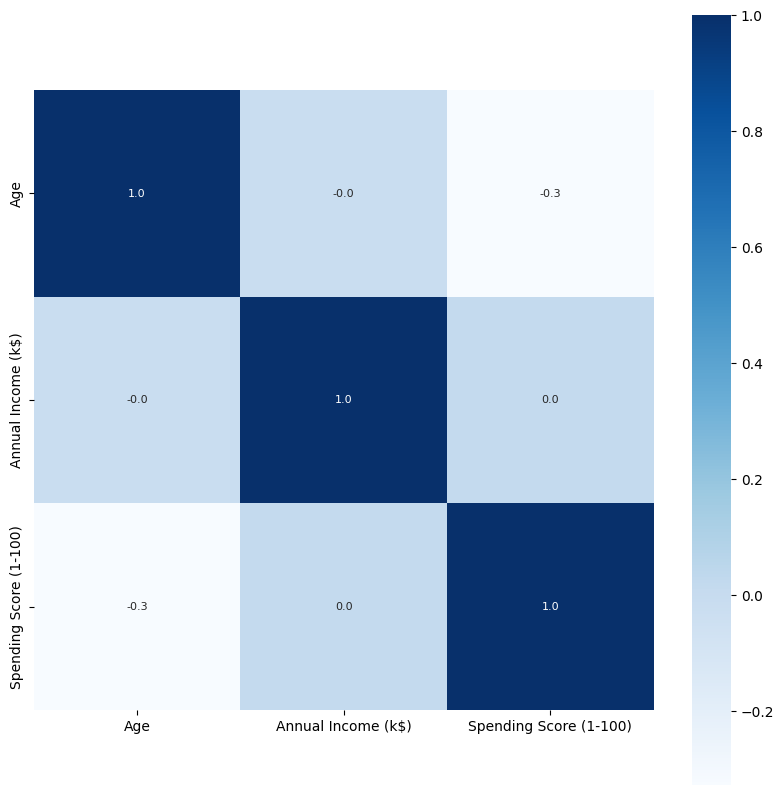

In [11]:
correlation = Mall_dataset.corr(numeric_only=True)
# Plot the heatmap
plt.figure(figsize=(10, 10))
sns.heatmap(correlation, cbar=True, square=True, fmt=".1f", annot=True, annot_kws={"size": 8}, cmap="Blues")
plt.show()

<Axes: xlabel='Annual Income (k$)', ylabel='Count'>

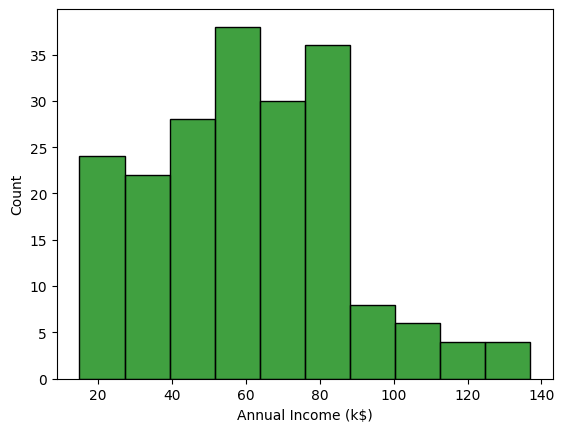

In [12]:
sns.histplot(Mall_dataset['Annual Income (k$)'],color="green")

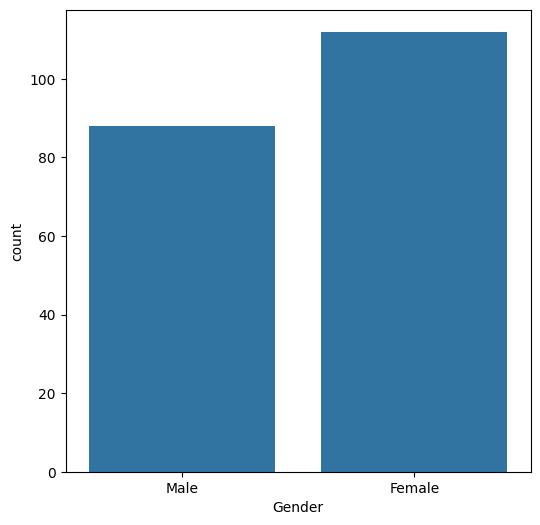

In [13]:
plt.figure(figsize=(6,6))
sns.countplot(x ='Gender',data=Mall_dataset)
plt.show()

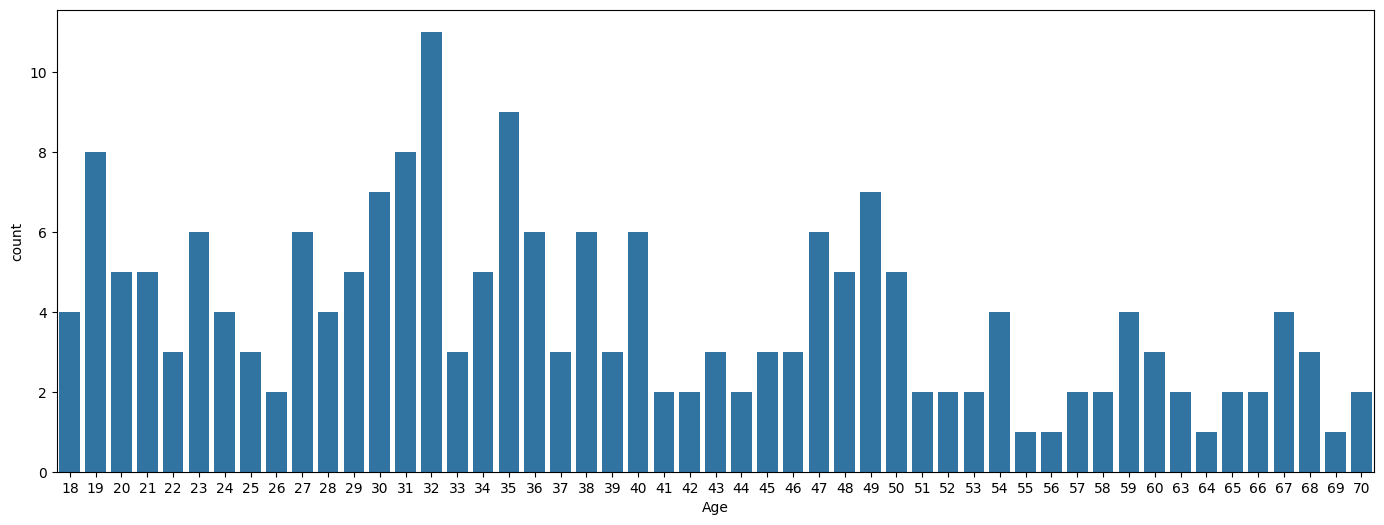

In [18]:
plt.figure(figsize=(17,6))
sns.countplot(x ='Age',data=Mall_dataset)
plt.show()

<Axes: xlabel='Age', ylabel='Count'>

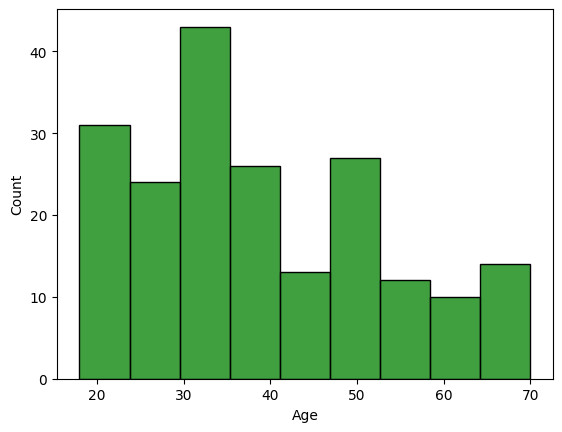

In [19]:
sns.histplot(Mall_dataset["Age"],color="green")

<Axes: xlabel='Spending Score (1-100)', ylabel='Count'>

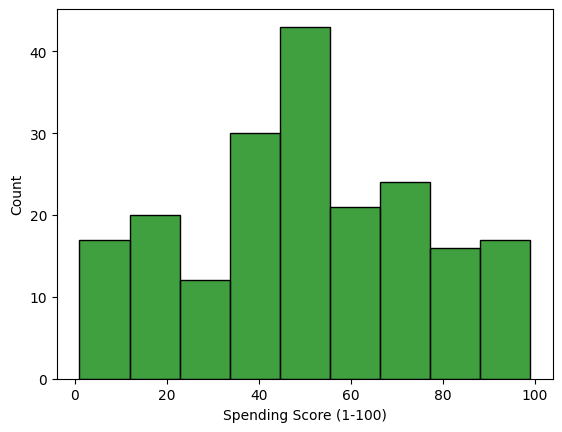

In [21]:
sns.histplot(Mall_dataset['Spending Score (1-100)'],color="green")

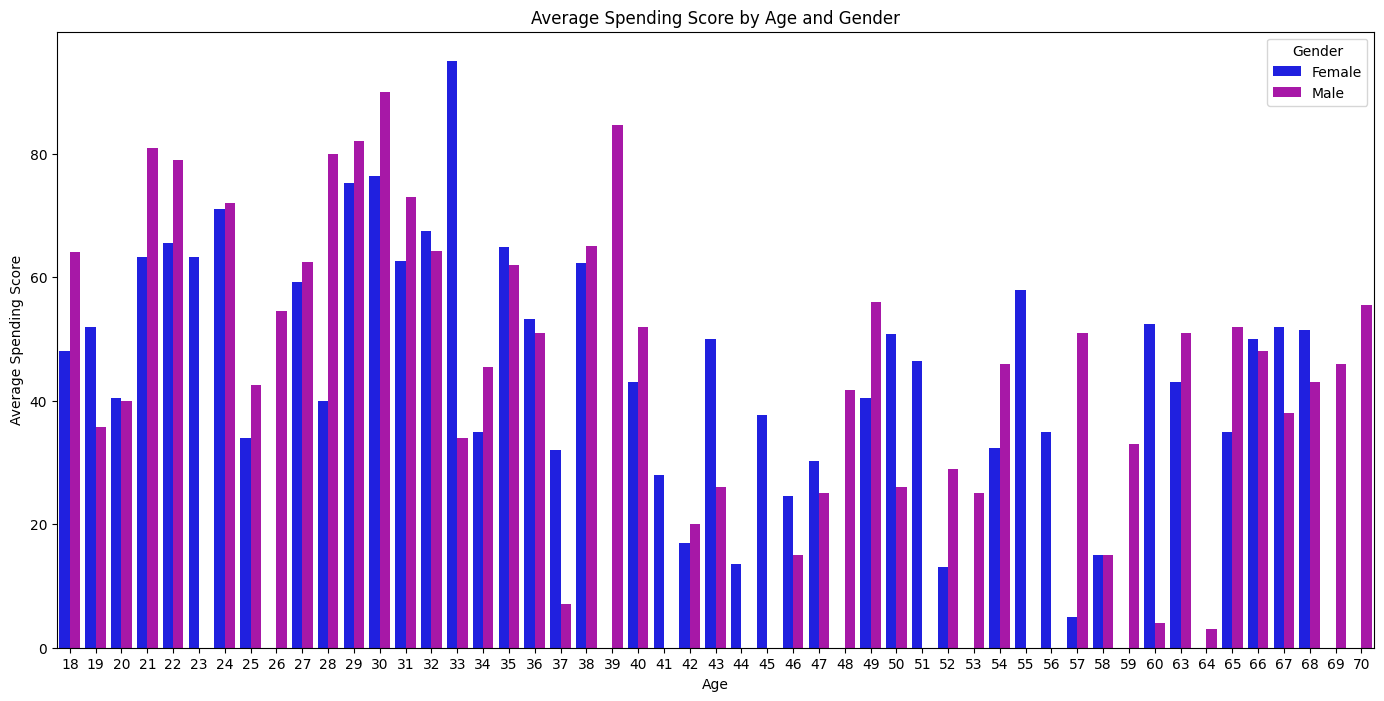

In [28]:
# Grouping data
grouped_data = Mall_dataset.groupby(['Age', 'Gender'])[['Spending Score (1-100)']].mean().reset_index()

# Set figure size
plt.figure(figsize=(17, 8))  # Adjust width and height as needed

# Plotting
sns.barplot(x='Age', y='Spending Score (1-100)', hue='Gender', data=grouped_data, palette=['b', 'm'])

# Adding titles and labels
plt.title('Average Spending Score by Age and Gender')
plt.ylabel('Average Spending Score')
plt.xlabel('Age')

# Show plot
plt.show()

<ipython-input-30-90cbd1542ed6>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y= 'Age', palette=["b", "m"], data=Mall_dataset)


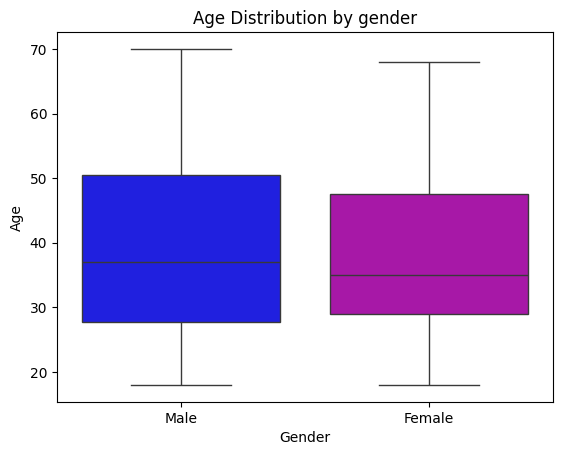

In [30]:
sns.boxplot(x='Gender', y= 'Age', palette=["b", "m"], data=Mall_dataset)
plt.title('Age Distribution by gender')
plt.show()

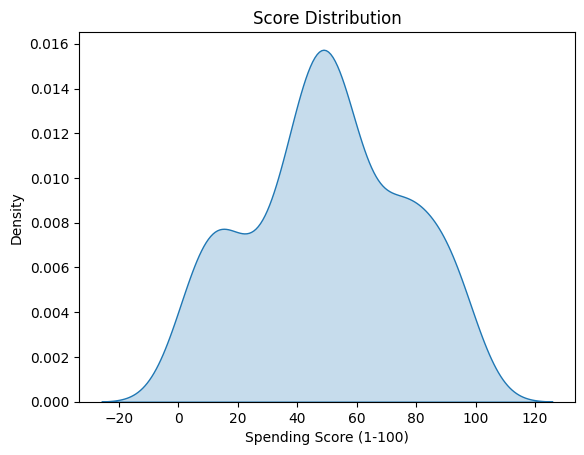

In [31]:
sns.kdeplot(Mall_dataset['Spending Score (1-100)'], fill='True')
plt.title("Score Distribution" )
plt.show()

#For clustering we dont need the Age and the Gender also

In [32]:
Mall_dataset = Mall_dataset.drop(columns=['Gender',"Age"], axis=1)

In [33]:
Mall_dataset.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [34]:
Mall_dataset.shape

(200, 2)

choosing the number of clusters

In [35]:
wcss = []
for i in range(1,11):
  kmeans = KMeans(n_clusters=i,init="k-means++",random_state=42)
  kmeans.fit(Mall_dataset)

  wcss.append(kmeans.inertia_)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` ex

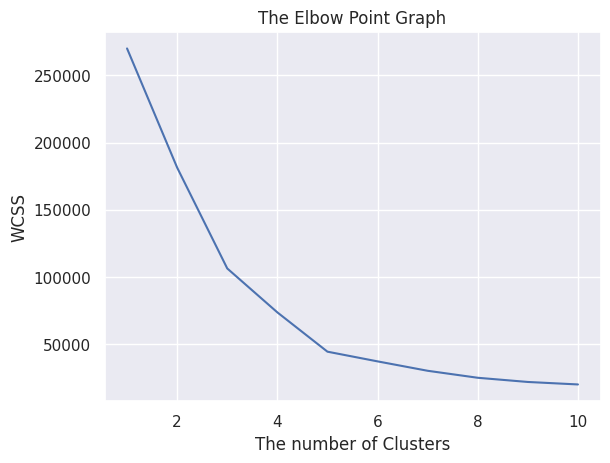

In [36]:
#Plot the elbow graph
sns.set()
plt.plot(range(1,11),wcss)
plt.title("The Elbow Point Graph")
plt.xlabel("The number of Clusters")
plt.ylabel("WCSS")
plt.show()

#Optimum number of cluster from the graph is 5

In [37]:
#Training the k-Means Model

kmeans = KMeans(n_clusters=5,init="k-means++",random_state=42)

#return a label for each data point based on their cluster
Y = kmeans.fit_predict(Mall_dataset)
print(Y)

[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


#Visualition all the clusters

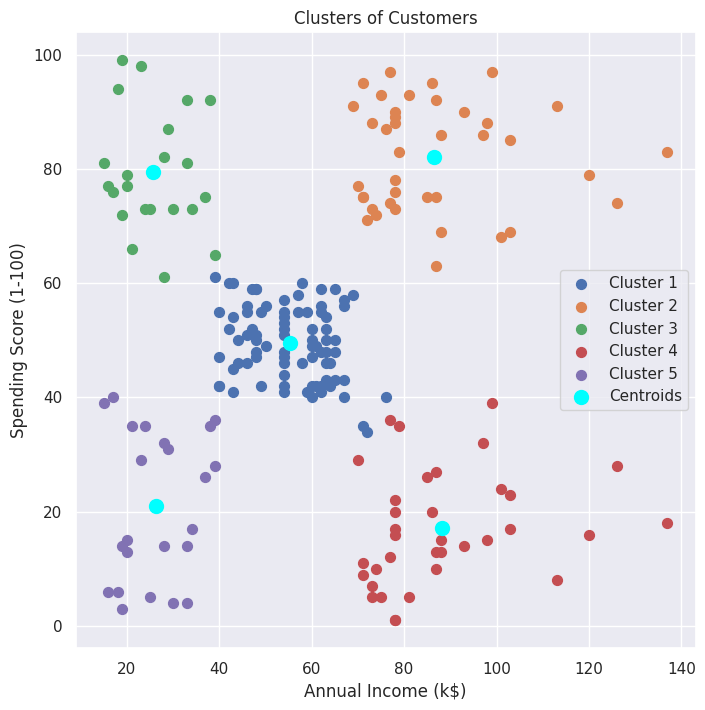

In [44]:
# Check if Mall_dataset is a DataFrame
if isinstance(Mall_dataset, pd.DataFrame):
    data = Mall_dataset[['Annual Income (k$)', 'Spending Score (1-100)']].values
else:
    data = Mall_dataset

plt.figure(figsize=(8, 8))

# Scatter plot for each cluster
for cluster in range(5):  # Adjust range if you have a different number of clusters
    plt.scatter(data[Y == cluster, 0], data[Y == cluster, 1], s=50, label=f"Cluster {cluster + 1}")

# Plot the centroids
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=100, c="cyan", label="Centroids")

plt.title('Clusters of Customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

In [47]:
# Assuming Y contains the cluster labels and Mall_dataset is your DataFrame

# Add the cluster labels to the DataFrame
Mall_dataset['Cluster'] = Y

# Analyze Clusters
cluster_analysis = Mall_dataset.groupby(by='Cluster').mean().reset_index()

# Display the analysis with background gradient
cluster_analysis.style.background_gradient(cmap='Greens')

,Cluster,Annual Income (k$),Spending Score (1-100)
0,0,55.296296,49.518519
1,1,86.538462,82.128205
2,2,25.727273,79.363636
3,3,88.200000,17.114286
4,4,26.304348,20.913043


In [48]:
Mall_dataset.head()

,Annual Income (k$),Spending Score (1-100),Cluster
0,15,39,4
1,15,81,2
2,16,6,4
3,16,77,2
4,17,40,4
